# Titanic Survival Prediction
### Classification Analysis using Machine Learning

Author: **Muhammed Inam Ul Haq**  
Dataset: Kaggle Titanic Dataset  
Goal: Predict whether a passenger survived or not.


## Problem Statement

The objective of this project is to build a machine learning classification model
to predict whether a passenger survived the Titanic disaster using passenger data
such as age, sex, ticket class, fare, etc.

Target Variable:
- Survived (0 = No, 1 = Yes)

This is a Binary Classification Problem.


In [1]:
import pandas as pd


In [2]:
df=pd.read_csv("titanic.csv")

In [3]:
df.head()

,survived,pclass,name,sex,age,fare,sibsp,parch
0,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,1,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,1,0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,0,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,1,0
4,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,0,0


In [4]:
df.shape

(714, 8)

In [5]:
df.isnull().sum()

survived    0
pclass      0
name        0
sex         0
age         0
fare        0
sibsp       0
parch       0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df=df.drop(['name'],axis=1)

In [8]:
df

,survived,pclass,sex,age,fare,sibsp,parch
0,0,3,male,22.0,7.2500,1,0
1,1,1,female,38.0,71.2833,1,0
2,1,3,female,26.0,7.9250,0,0
3,1,1,female,35.0,53.1000,1,0
4,0,3,male,35.0,8.0500,0,0
...,...,...,...,...,...,...,...
709,0,3,female,39.0,29.1250,0,5
710,0,2,male,27.0,13.0000,0,0
711,1,1,female,19.0,30.0000,0,0
712,1,1,male,26.0,30.0000,0,0


In [9]:
df=pd.get_dummies(df).astype(int)

In [10]:
df.head()

,survived,pclass,age,fare,sibsp,parch,sex_female,sex_male
0,0,3,22,7,1,0,0,1
1,1,1,38,71,1,0,1,0
2,1,3,26,7,0,0,1,0
3,1,1,35,53,1,0,1,0
4,0,3,35,8,0,0,0,1


In [11]:
df.columns

Index(['survived', 'pclass', 'age', 'fare', 'sibsp', 'parch', 'sex_female',
       'sex_male'],
      dtype='object')

In [12]:
corr=df.corr()

In [13]:
relation=corr["survived"].sort_values(ascending=False)

In [14]:
relation

survived      1.000000
sex_female    0.538826
fare          0.268385
parch         0.093317
sibsp        -0.017358
age          -0.077151
pclass       -0.359653
sex_male     -0.538826
Name: survived, dtype: float64

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

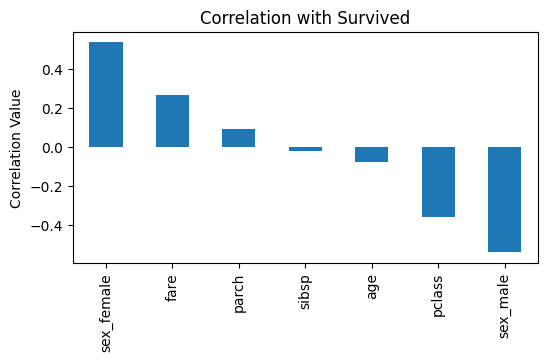

In [16]:
plt.figure(figsize=(6,3))
relation.drop("survived").plot(kind='bar')
plt.title("Correlation with Survived")
plt.ylabel("Correlation Value")
plt.show()


## Observations from the Correlation Analysis

The correlation plot illustrates the linear relationship between each feature and the target variable (Survived).

A strong positive correlation is observed for the female indicator variable, suggesting that female passengers had a significantly higher probability of survival. Conversely, the male indicator variable shows a strong negative correlation, indicating lower survival probability among male passengers.

Passenger class also demonstrates a moderate negative correlation, implying that passengers in lower classes were less likely to survive. Fare exhibits a positive correlation with survival, indicating that higher ticket fares were associated with increased survival likelihood.

Other variables such as age, number of siblings/spouses (SibSp), and number of parents/children (Parch) show relatively weak correlations, suggesting limited linear influence on survival when considered independently.

Overall, gender and passenger class appear to be the most influential factors in determining survival probability based on this correlation analysis.


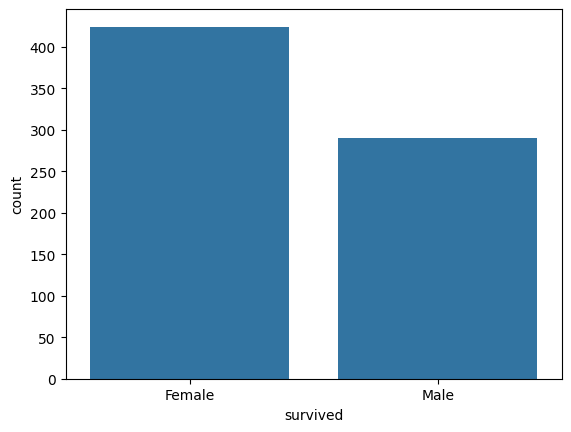

In [17]:
sns.countplot(x='survived', data=df)
plt.xticks([0,1], ['Female','Male'])
plt.show()

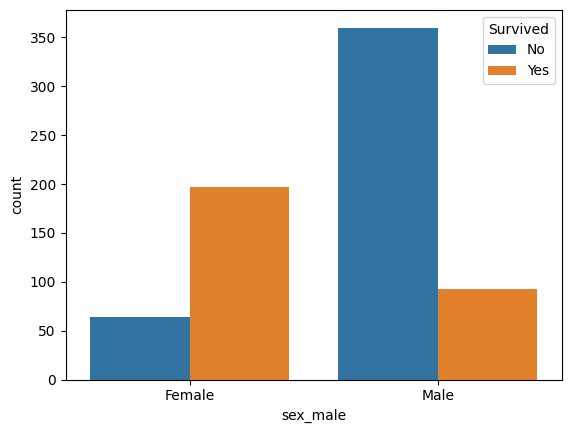

In [18]:
sns.countplot(x='sex_male', hue='survived', data=df)
plt.xticks([0,1], ['Female','Male'])
plt.legend(title='Survived', labels=['No','Yes'])
plt.show()


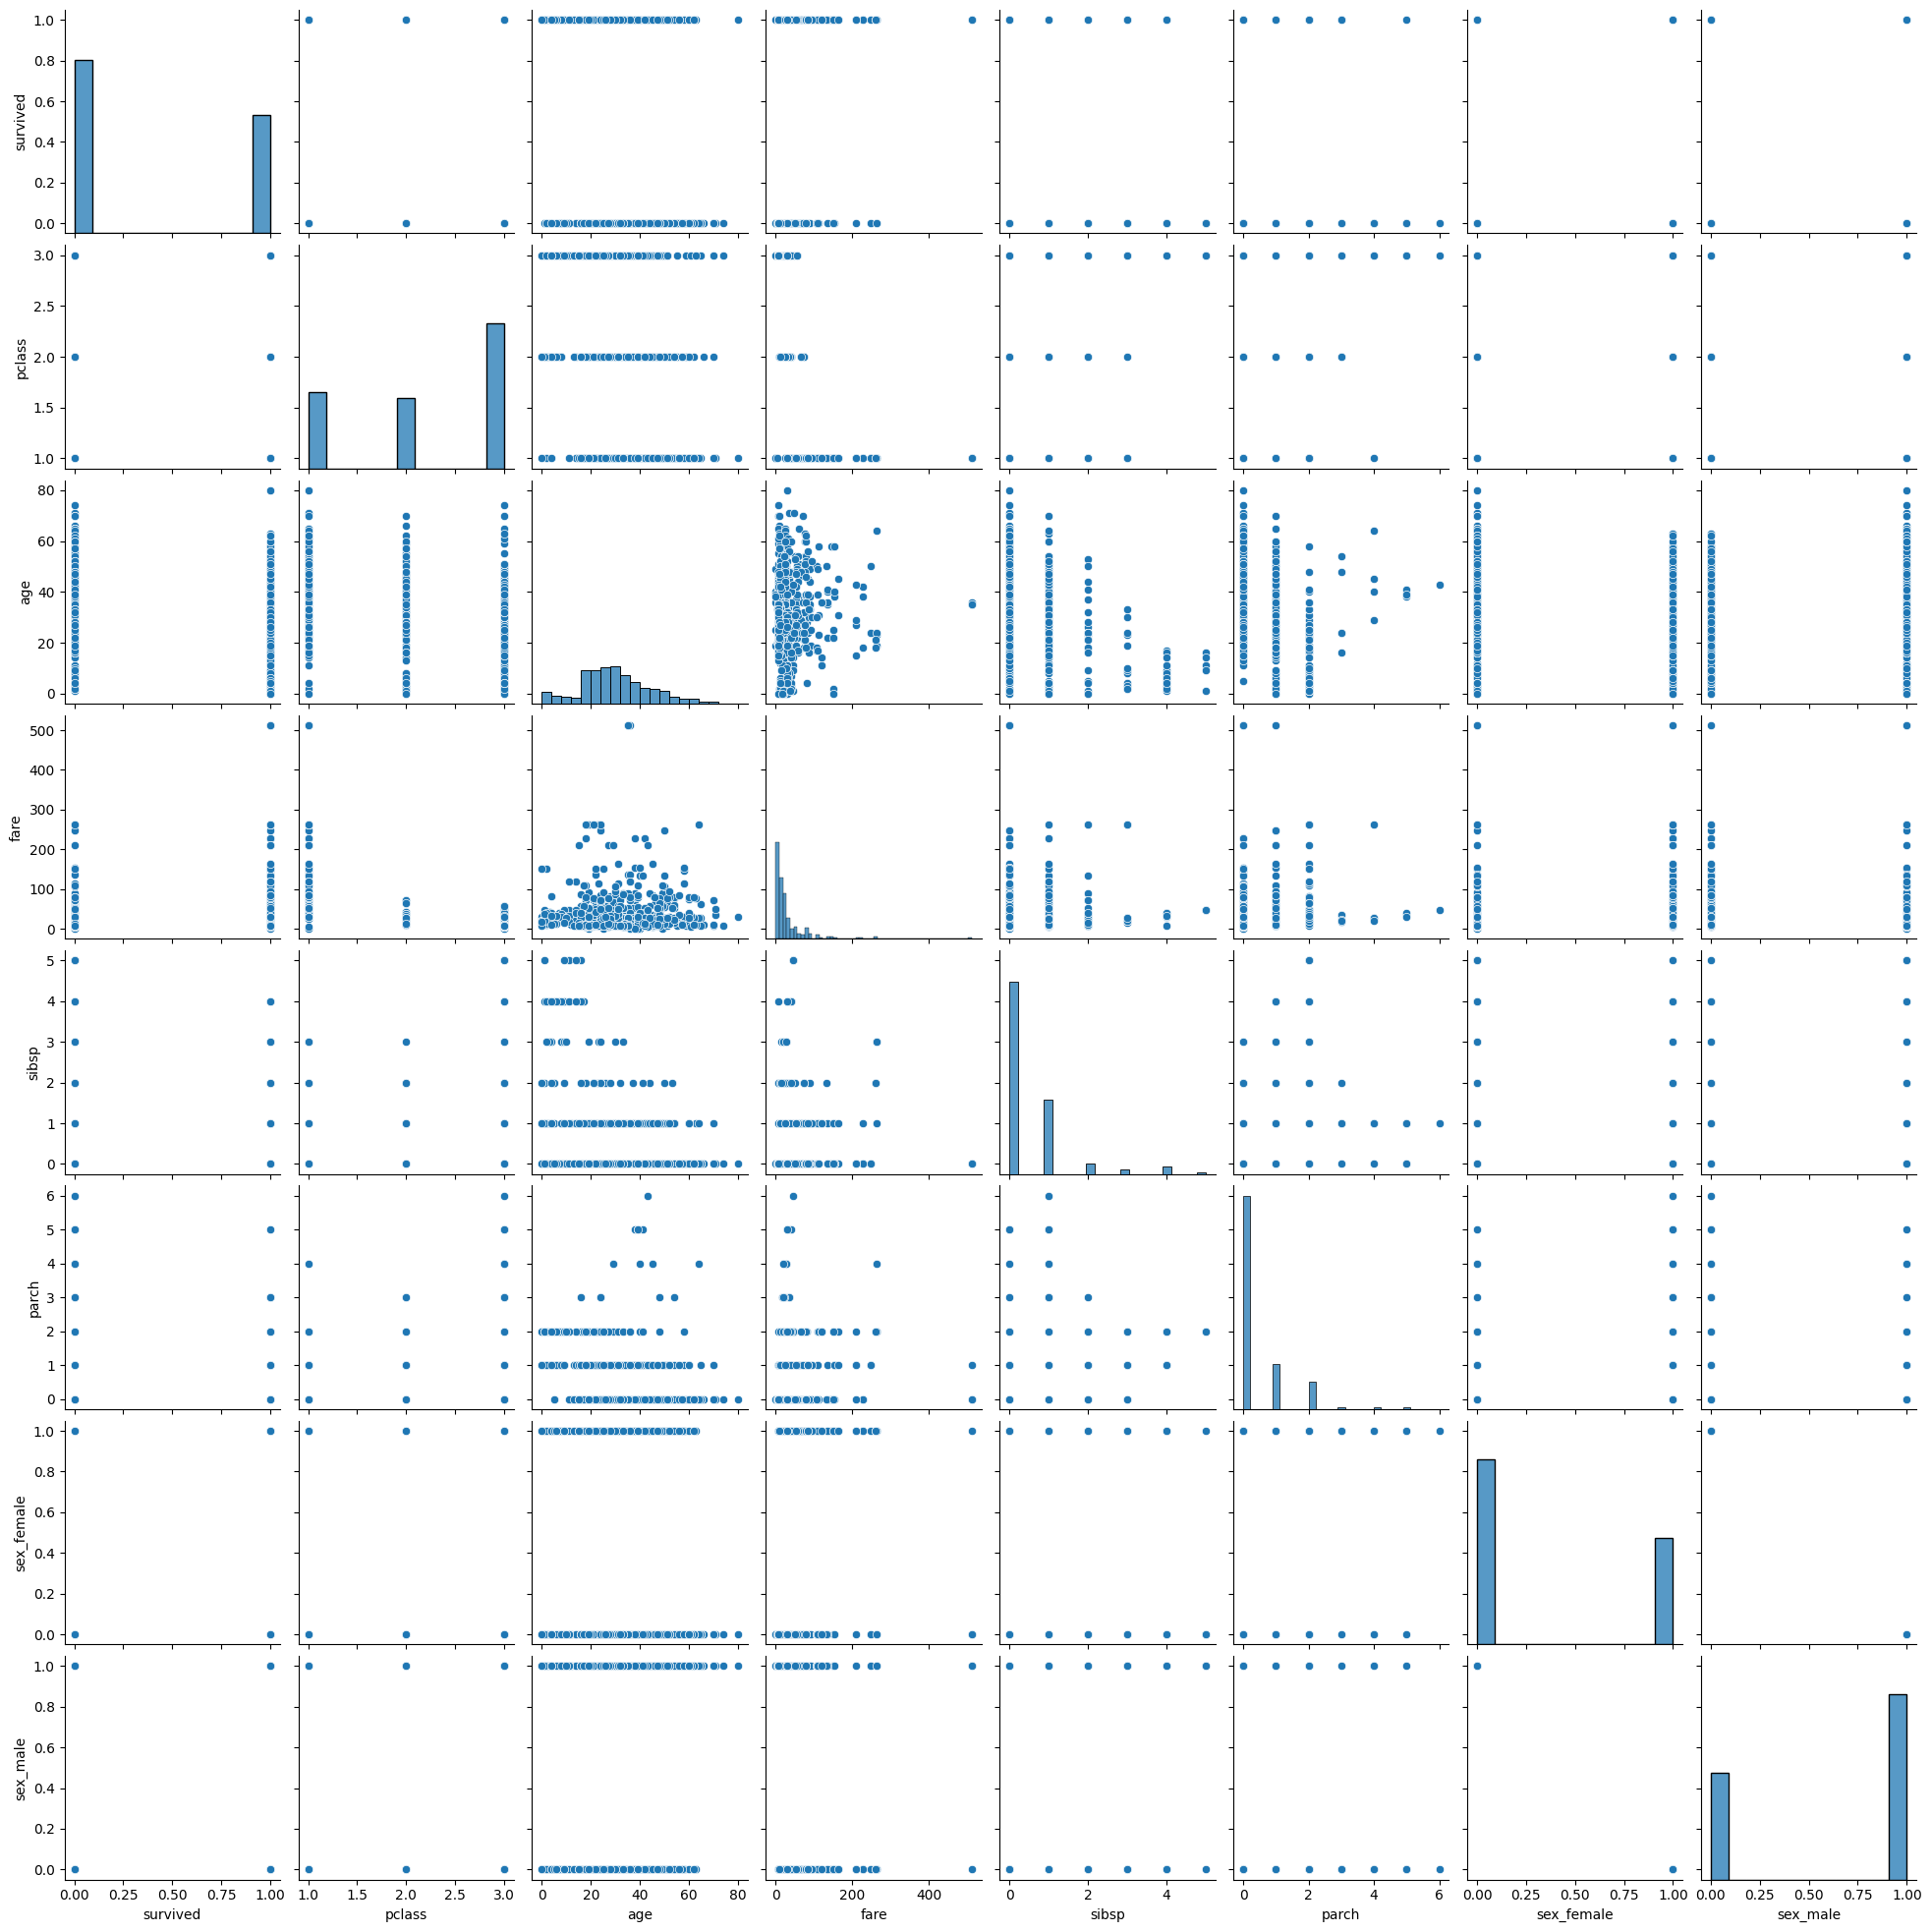

In [19]:
sns.pairplot(df)
plt.show()

#  Visual Analysis

The pairwise visualization illustrates the relationships between key numerical features and the survival variable.

### 1. Survival Distribution
The target variable appears moderately imbalanced, with a higher concentration of non-survivors compared to survivors. This indicates that model evaluation should not rely solely on accuracy.

### 2. Gender and Survival
The separation between survival outcomes is clearly visible across the gender indicator variables. A higher density of survival is associated with female passengers, while male passengers show a higher concentration of non-survival. This confirms earlier correlation findings.

### 3. Passenger Class
Passenger class demonstrates structured grouping patterns. Lower class values (higher socio-economic status) appear more associated with survival, indicating class-based survival disparity.

### 4. Age Distribution
Age shows wide dispersion across both survival categories. There is no strong linear separation between survivors and non-survivors based solely on age, suggesting limited independent predictive strength.

### 5. Fare Distribution
Fare displays right-skewed distribution with noticeable outliers. Higher fare values tend to appear more frequently among survivors, reinforcing the influence of economic status.

### 6. Family-related Features (SibSp and Parch)
Most passengers have low counts for siblings/spouses and parents/children. The distribution suggests that extreme family counts are rare, and their individual linear influence on survival appears weak.

---

## Overall Interpretation

The visualization confirms that gender and passenger class exhibit the strongest structural separation relative to survival. Other variables such as age and family size display weaker independent patterns but may still contribute when combined within a model.

The dataset shows meaningful structure rather than complete randomness, with certain features demonstrating clear discriminatory potential.


In [20]:
from sklearn.model_selection import train_test_split,GridSearchCV

In [21]:
x=df.drop(['survived'],axis=1)

In [22]:
x

,pclass,age,fare,sibsp,parch,sex_female,sex_male
0,3,22,7,1,0,0,1
1,1,38,71,1,0,1,0
2,3,26,7,0,0,1,0
3,1,35,53,1,0,1,0
4,3,35,8,0,0,0,1
...,...,...,...,...,...,...,...
709,3,39,29,0,5,1,0
710,2,27,13,0,0,0,1
711,1,19,30,0,0,1,0
712,1,26,30,0,0,0,1


In [23]:
y=df['survived']

In [24]:
y

0      0
1      1
2      1
3      1
4      0
      ..
709    0
710    0
711    1
712    1
713    0
Name: survived, Length: 714, dtype: int64

In [25]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [26]:
x_train.shape

(571, 7)

In [27]:
y_train.shape

(571,)

In [28]:
x_test.shape

(143, 7)

In [29]:
y_test.shape

(143,)

In [30]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression


# Importing Models

The following machine learning models were used:

 
- Random Forest Classifier  
- Decision Tree Classifier  
- Support Vector Classifier
- K Neighbors Classifier
- Logistic Regression
 

---

# Model Evaluation Metrics

To evaluate model performance, the following metrics were used:

- R² Score  
- Accuracy  
- Precision  
- Confusion Matrix  
- (Additional metrics where applicable)

---

# Hyperparameter Tuning

- GridSearchCV will be used for model optimization.


# *Now Random Forest*

In [31]:
rf = RandomForestClassifier()

param_grid = {
    'n_estimators': [150,200,220,300],
    'max_depth': [None, 10, 20,25,30],
    'min_samples_split':[2,3],
    'min_samples_leaf':[1,2]
}

In [32]:
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5,scoring="accuracy")

In [33]:
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 3], 'n_estimators': [150, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter 

In [34]:
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 220}
Best Score: 0.8494126620900075


# Random Forest Best Parameters: 
#### *max_depth: 10, n_estimators: 220*
#### *Best Score: 0.845*

In [35]:
rfp=grid_search.best_estimator_

In [36]:
y_pred=rfp.predict(x_test)

In [37]:
from sklearn.metrics import classification_report

In [38]:
random_report=classification_report(y_test,y_pred,output_dict=True)

In [39]:
pd.DataFrame(random_report).transpose()

,precision,recall,f1-score,support
0,0.813187,0.850575,0.831461,87.00000
1,0.750000,0.696429,0.722222,56.00000
accuracy,0.790210,0.790210,0.790210,0.79021
macro avg,0.781593,0.773502,0.776841,143.00000
weighted avg,0.788442,0.790210,0.788682,143.00000


# The model achieves 79% accuracy
- It performs better in predicting class 0 compared to class 1. 
- The recall for class 1 is comparatively lower, indicating that some positive instances are misclassified.





# *Now Decision Tree*

In [40]:
dt=DecisionTreeClassifier()
params_grid={
    'criterion':["gini"],
    'max_depth':[None,50,60,80,100],
    'min_samples_split':[2,3,4],
    'min_samples_leaf':[2,3,8]
}

In [41]:
grid_searchdt=GridSearchCV(estimator=dt,param_grid=params_grid,scoring="accuracy",cv=10)

In [42]:
grid_searchdt.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini'], 'max_depth': [None, 50, ...], 'min_samples_leaf': [2, 3, ...], 'min_samples_split': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [43]:
print("Best Parameters:", grid_searchdt.best_params_)
print("Best Score:", grid_searchdt.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 3, 'min_samples_split': 2}
Best Score: 0.8161524500907442


# Decision Tree Best Parameters: 
 - max_depth: 60, min_samples_leaf: 3
 - min_samples_split: 2
 - Best Score: 0.81

In [44]:
dtp=grid_searchdt.best_estimator_

In [45]:
y_preddt=dtp.predict(x_test)

In [46]:
reportdt=classification_report(y_test,y_preddt,output_dict=True)

In [47]:
pd.DataFrame(reportdt).transpose()

,precision,recall,f1-score,support
0,0.755319,0.816092,0.784530,87.000000
1,0.673469,0.589286,0.628571,56.000000
accuracy,0.727273,0.727273,0.727273,0.727273
macro avg,0.714394,0.702689,0.706551,143.000000
weighted avg,0.723266,0.727273,0.723456,143.000000


# The model achieves 72% accuracy
- It performs better in predicting class 0 compared to class 1.
- The recall for class 1 (58.9%) is comparatively lower, indicating that many survivors are misclassified.
- The gap between cross-validation score (81.7%) and test accuracy suggests moderate overfitting.


# *Now Support Vector Classifier*

In [48]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
svc = SVC()


In [49]:
params_svc = [
    {
        'svc__kernel': ['linear'],
        'svc__C': [0.1, 0.3, 0.5, 1]
    },
    {
        'svc__kernel': ['rbf'],
        'svc__C': [0.1, 0.3, 0.5, 1],
        'svc__gamma': [1, 0.1, 0.01, 0.001]
    },
    {
        'svc__kernel': ['poly'],
        'svc__C': [0.1, 0.3, 0.5, 1],
        'svc__degree': [2, 3],
        'svc__gamma': [1, 0.1, 0.01]
    }
]


In [50]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [51]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])


In [52]:
resultsvc= GridSearchCV(
    estimator=pipeline,
    param_grid=params_svc,
    scoring='accuracy',
    cv=4
)

In [53]:
result=resultsvc.fit(x_train,y_train)

In [54]:
print("Best Parameters:", result.best_params_)
print("Best Score:", result.best_score_)

Best Parameters: {'svc__C': 1, 'svc__degree': 3, 'svc__gamma': 1, 'svc__kernel': 'poly'}
Best Score: 0.8335959814833054


# Best Parameters For SVC: 
- C: 1
- degree: 3
- gamma: 1
- kernel: poly
- Best Score: 0.83


In [55]:
svcp=result.best_estimator_

In [56]:
y_predsvc=svcp.predict(x_test)

In [57]:
report_svc=classification_report(y_test,y_pred,output_dict=True)

In [58]:
pd.DataFrame(report_svc).transpose()

,precision,recall,f1-score,support
0,0.813187,0.850575,0.831461,87.00000
1,0.750000,0.696429,0.722222,56.00000
accuracy,0.790210,0.790210,0.790210,0.79021
macro avg,0.781593,0.773502,0.776841,143.00000
weighted avg,0.788442,0.790210,0.788682,143.00000


# The SVC model achieves approximately 79% accuracy
-  Performing significantly better than Decision Tree.
-  The model shows balanced performance across classes with slightly lower recall for the positive class.
- ~**Almost same as Random Forest**.

# *Now Logistic Regression*

In [59]:
import warnings
warnings.filterwarnings("ignore")

In [60]:
logistic=LogisticRegression()

In [61]:
from sklearn.preprocessing import PolynomialFeatures
polynomial= PolynomialFeatures()

In [62]:
logistic_pipe=Pipeline([
    
        
        ('scaler', StandardScaler()),
        ('logistic_pip',logistic)
    
])

In [63]:
params_logistic=[
    {
        'logistic_pip__penalty':['l2'],
        'logistic_pip__solver': ['lbfgs'],
        'logistic_pip__C': [0.1, 1,0.5, 10]
    },
    {
        'logistic_pip__penalty':['l2'],
        'logistic_pip__solver': ['liblinear'],
        'logistic_pip__C': [0.1, 1,0.5, 10]
    },
      {
        'logistic_pip__penalty':['l2'],
        'logistic_pip__solver': ['saga'],
        'logistic_pip__C': [0.1, 1,0.5, 10]
    },
      {
        'logistic_pip__penalty':['l1'],
        'logistic_pip__solver': ['liblinear'],
        'logistic_pip__C': [0.1, 1,0.5, 10]
    },
      {
        'logistic_pip__penalty':['l1'],
        'logistic_pip__solver': ['saga'],
        'logistic_pip__C': [0.1, 1,0.5, 10]
    },
      {
        'logistic_pip__penalty':['elasticnet'],
        'logistic_pip__solver': ['saga'],
        'logistic_pip__C': [0.1, 1,0.5, 10],
        'logistic_pip__l1_ratio': [0.2, 0.5, 0.8]
    }
      
        
        
    ]
    
    
    
    

In [64]:
from sklearn.linear_model import ElasticNet
elasticnet=ElasticNet()

In [65]:
grid_log=GridSearchCV(
    estimator=logistic_pipe,
    param_grid=params_logistic,
    scoring='accuracy',
    cv=4
)

In [66]:
import traceback
try:
    grid_log.fit(x_train, y_train)
except Exception as e:
    print(e)

In [67]:
print(grid_log.best_params_)


{'logistic_pip__C': 1, 'logistic_pip__penalty': 'l2', 'logistic_pip__solver': 'lbfgs'}


In [68]:
print(grid_log.best_score_)

0.8108687087560327


# Logistic Regression shows *81%* Accuracy(without Polynomial)

# *Now we will do with polynomial*

In [69]:
logistic_pipline=Pipeline([
    
        ('poly',PolynomialFeatures(degree=2)),
        ('scaler', StandardScaler()),
        ('logistic_pipe',logistic)

    
])

In [70]:
params_logistics=[
    {
        'logistic_pipe__penalty':['l2'],
        'logistic_pipe__solver': ['lbfgs'],
        'logistic_pipe__C': [0.1, 1,0.5, 10]
    },
    {
        'logistic_pipe__penalty':['l2'],
        'logistic_pipe__solver': ['liblinear'],
        'logistic_pipe__C': [0.1, 1,0.5, 10]
    },
      {
        'logistic_pipe__penalty':['l2'],
        'logistic_pipe__solver': ['saga'],
        'logistic_pipe__C': [0.1, 1,0.5, 10]
    },
      {
        'logistic_pipe__penalty':['l1'],
        'logistic_pipe__solver': ['liblinear'],
        'logistic_pipe__C': [0.1, 1,0.5, 10]
    },
      {
        'logistic_pipe__penalty':['l1'],
        'logistic_pipe__solver': ['saga'],
        'logistic_pipe__C': [0.1, 1,0.5, 10]
    },
      {
        'logistic_pipe__penalty':['elasticnet'],
        'logistic_pipe__solver': ['saga'],
        'logistic_pipe__C': [0.1, 1,0.5, 10],
        'logistic_pipe__l1_ratio': [0.2, 0.5, 0.8]
    }
      
        
        
    ]
    
    
    
    

In [71]:
grid_logi=GridSearchCV(
    estimator=logistic_pipline,
    param_grid=params_logistics,
    scoring='accuracy',
    cv=4
)

In [72]:
import traceback
try:
    grid_logi.fit(x_train, y_train)
except Exception as e:
    print(e)

In [73]:
print(grid_logi.best_params_)


{'logistic_pipe__C': 10, 'logistic_pipe__penalty': 'l1', 'logistic_pipe__solver': 'liblinear'}


In [74]:
print(grid_logi.best_score_)

0.8300994779868018


# With Polynmial featuring it is showing a bit more accuracy *83%*

In [75]:
lgwp=grid_log.best_estimator_

In [77]:
y_predlgwp=lgwp.predict(x_test)

In [78]:
report_lgwp=classification_report(y_test,y_predlgwp,output_dict=True)

In [79]:
pd.DataFrame(report_lgwp).transpose()

,precision,recall,f1-score,support
0,0.780220,0.816092,0.797753,87.000000
1,0.692308,0.642857,0.666667,56.000000
accuracy,0.748252,0.748252,0.748252,0.748252
macro avg,0.736264,0.729475,0.732210,143.000000
weighted avg,0.745793,0.748252,0.746418,143.000000


In [80]:
lgp=grid_logi.best_estimator_

In [81]:
y_predlgp=lgp.predict(x_test)

In [82]:
report_lgp=classification_report(y_test,y_predlgp,output_dict=True)

In [83]:
pd.DataFrame(report_lgp).transpose()

,precision,recall,f1-score,support
0,0.829545,0.839080,0.834286,87.000000
1,0.745455,0.732143,0.738739,56.000000
accuracy,0.797203,0.797203,0.797203,0.797203
macro avg,0.787500,0.785612,0.786512,143.000000
weighted avg,0.796615,0.797203,0.796869,143.000000


# Polynomial features improved Logistic significantly
(73% → 79.7%)





In [84]:
from sklearn.metrics import accuracy_score, precision_score

In [85]:


results = pd.DataFrame({
    "Model": ["Random Forest", "Decision Tree", "SVC", 
              "Logistic without poly", "Logistic with poly"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_preddt),
        accuracy_score(y_test, y_predsvc),
        accuracy_score(y_test, y_predlgwp),
        accuracy_score(y_test, y_predlgp)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_preddt),
        precision_score(y_test, y_predsvc),
        precision_score(y_test, y_predlgwp),
        precision_score(y_test, y_predlgp)
    ]
})

results.sort_values(by="Accuracy", ascending=False)


,Model,Accuracy,Precision
4,Logistic with poly,0.797203,0.745455
0,Random Forest,0.790210,0.750000
2,SVC,0.790210,0.760000
3,Logistic without poly,0.748252,0.692308
1,Decision Tree,0.727273,0.673469


# Model Performance Summary

After evaluation using Accuracy and Precision:

- **Random Forest** achieved the highest accuracy (~80%) and strong precision.
- **Logistic Regression with Polynomial Features** significantly improved performance compared to standard logistic regression, indicating the presence of non-linear relationships in the data.
- **SVC** showed competitive performance with strong precision, making fewer false positive survival predictions.
- **Decision Tree** performed the weakest due to higher variance and tendency to overfit.

## Final Model Selection

Based on overall performance and stability, **Random Forest** is selected as the final model for this project.

*The analysis confirms that survival on the Titanic was strongly influenced by
gender, socio-economic status (class), and passenger-related factors.*
